In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import seaborn as sns
import numpy as np

COLOR_MALE = "#66b3ff"
COLOR_FEMALE = "#ff9999"
RESOLUTION = 500

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

ibm_df = pd.read_csv("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(ibm_df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


# Slide 2

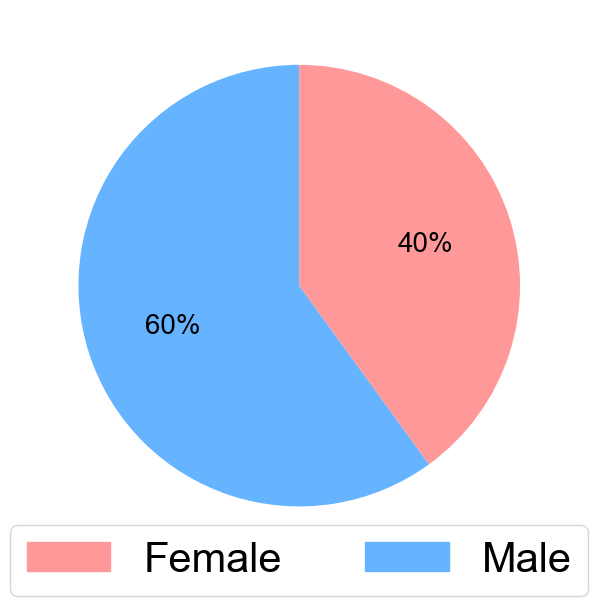

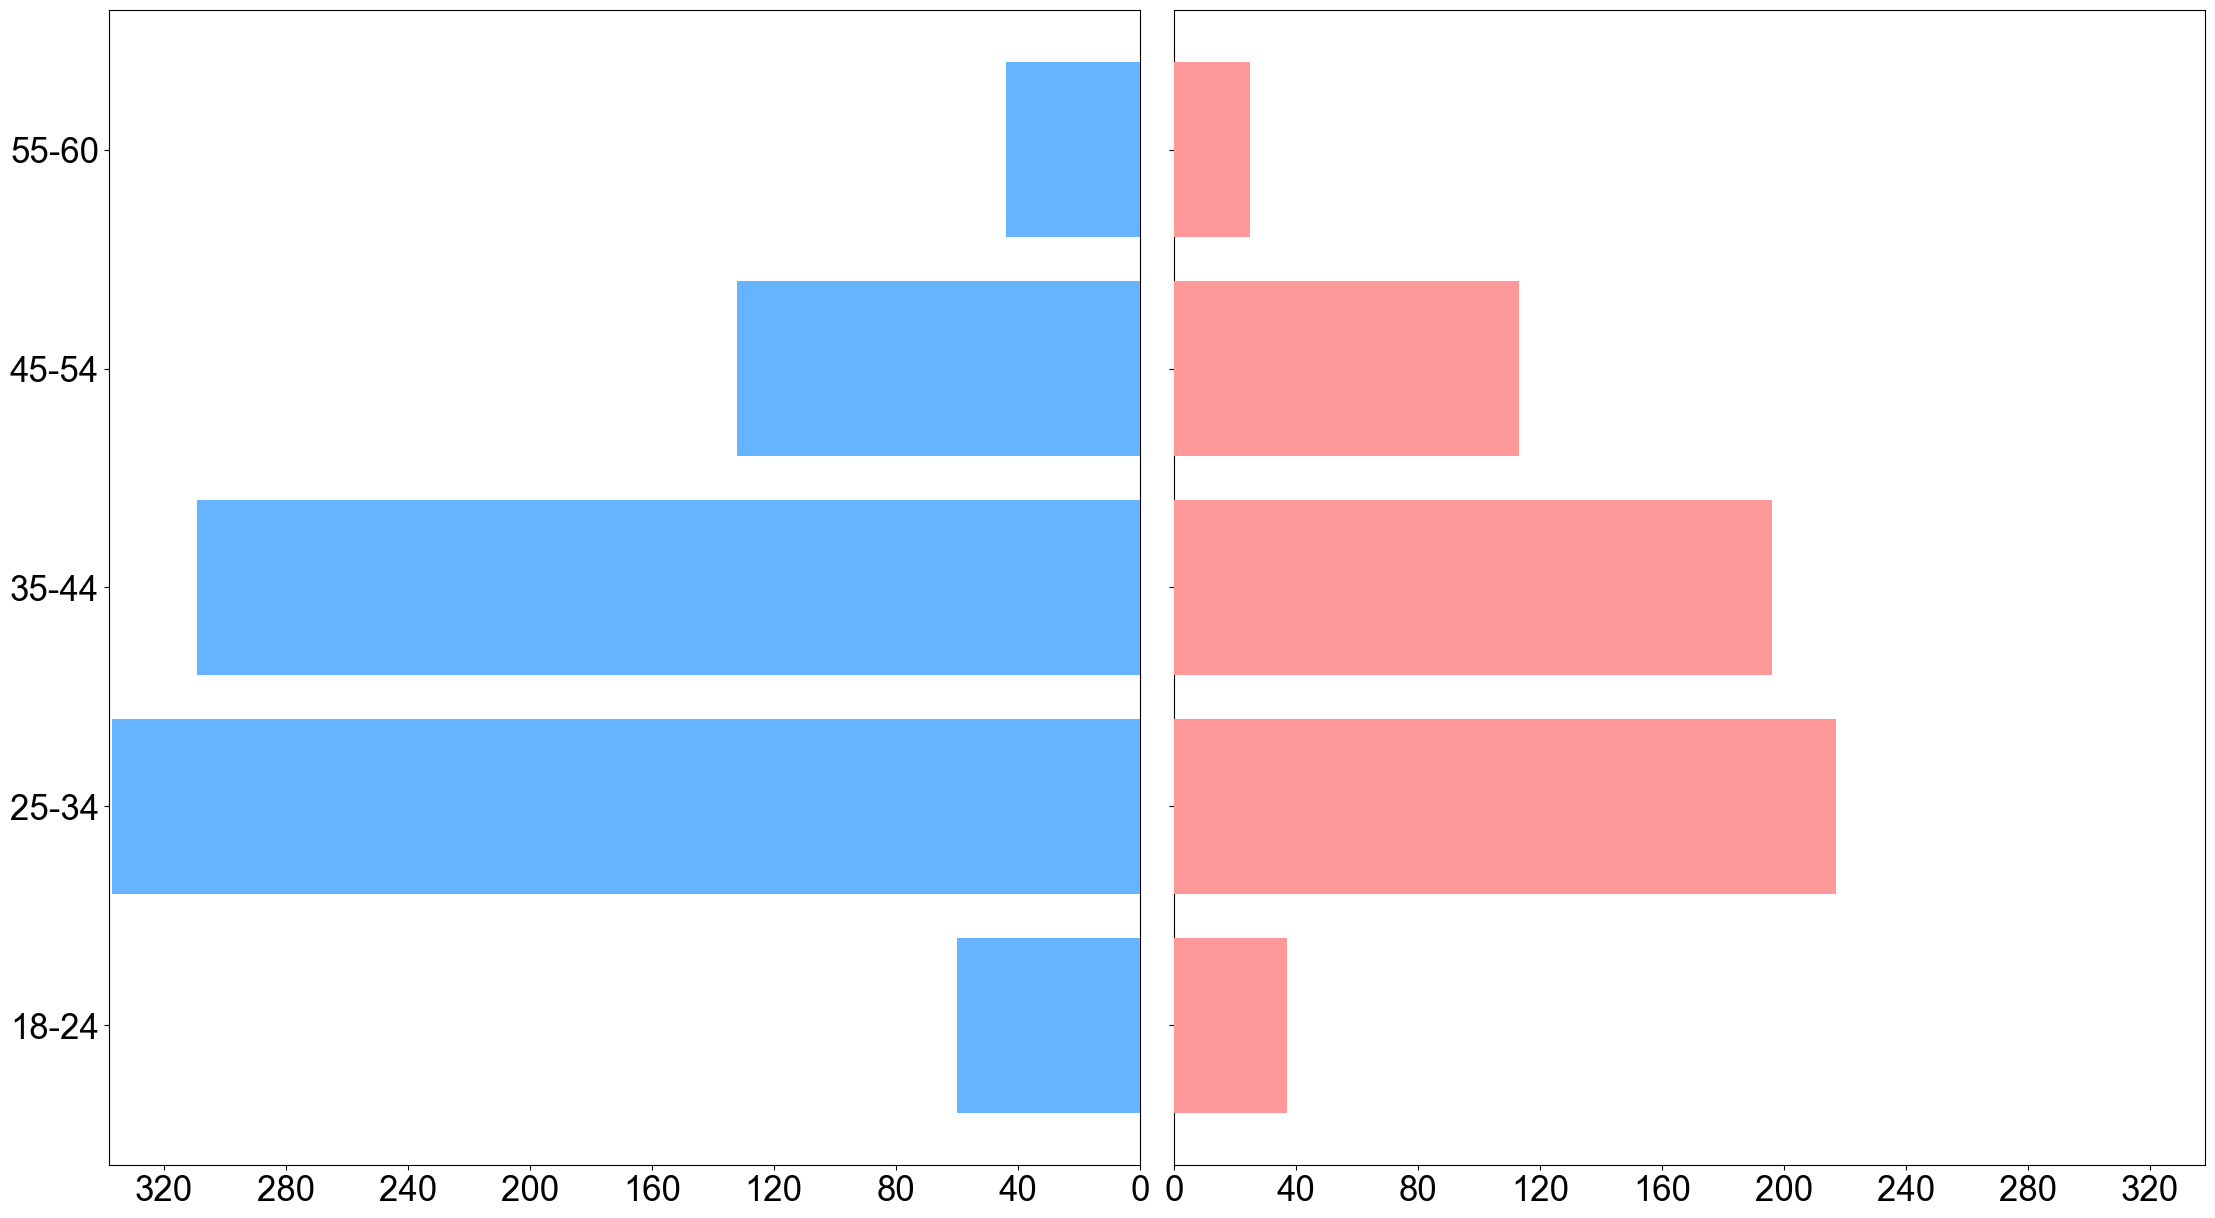

In [44]:
# Slide 2
gender_counts = ibm_df['Gender'].value_counts()
DESCRIPTION_FONTSIZE = 20

# 1. Pie Chart for Gender Distribution
plt.figure(figsize=(6.74, 6.08))
plt.pie(gender_counts, labels=None, autopct='%1.0f%%', startangle=90, colors=[COLOR_MALE, COLOR_FEMALE], textprops={'fontsize': DESCRIPTION_FONTSIZE})
plt.title('')
plt.ylabel('') # Hide the y-label

female_patch_pie = mpatches.Patch(color=COLOR_FEMALE, label='Female')
male_patch_pie = mpatches.Patch(color=COLOR_MALE, label='Male')

plt.legend(handles=[female_patch_pie, male_patch_pie], loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=30)

plt.tight_layout()
plt.savefig('reports/gender_pie_chart_subset.png', dpi=RESOLUTION)

# 2. Population Pyramid for Age Distribution

# Define new bins and labels for the 18-60 age range
bins = [18, 25, 35, 45, 55, 61]
labels = ['18-24', '25-34', '35-44', '45-54', '55-60']
ibm_df['AgeGroup'] = pd.cut(ibm_df['Age'], bins=bins, labels=labels, right=False)

# Separate data by gender and count age groups
male_counts = ibm_df[ibm_df['Gender'] == 'Male']['AgeGroup'].value_counts().sort_index()
female_counts = ibm_df[ibm_df['Gender'] == 'Female']['AgeGroup'].value_counts().sort_index()

# Reindex to ensure both series have the same age groups, filling missing with 0
all_labels = ibm_df['AgeGroup'].cat.categories
male_counts = male_counts.reindex(all_labels, fill_value=0)
female_counts = female_counts.reindex(all_labels, fill_value=0)

# Create the population pyramid plot
y = np.arange(len(labels))
fig, axes = plt.subplots(ncols=2, sharey=True, figsize=(22.25, 13.19))

# Plot male data
axes[0].barh(y, -male_counts, align='center', color=COLOR_MALE, zorder=10)
axes[0].set_xlabel('', fontsize=DESCRIPTION_FONTSIZE)
axes[0].tick_params(axis='x', labelsize=DESCRIPTION_FONTSIZE+5)
max_count = max(male_counts.max(), female_counts.max())
axes[0].set_xlim(left=-max_count-1, right=0)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{abs(int(x))}'))
axes[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Plot female data
axes[1].barh(y, female_counts, align='center', color=COLOR_FEMALE, zorder=10)
axes[1].set_xlabel('', fontsize=DESCRIPTION_FONTSIZE)
axes[1].tick_params(axis='x', labelsize=DESCRIPTION_FONTSIZE+5)
axes[1].set_xlim(left=0, right=max_count+1)
axes[1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Adjust layout and labels
fig.suptitle('')
axes[0].tick_params(axis='y', labelsize=DESCRIPTION_FONTSIZE+5)
plt.yticks(y, labels)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig('reports/population_pyramid_subset.png', dpi=RESOLUTION)

# Slide 3

['Sales', 'Research & Development', 'Human Resources']
['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', 'Human Resources']


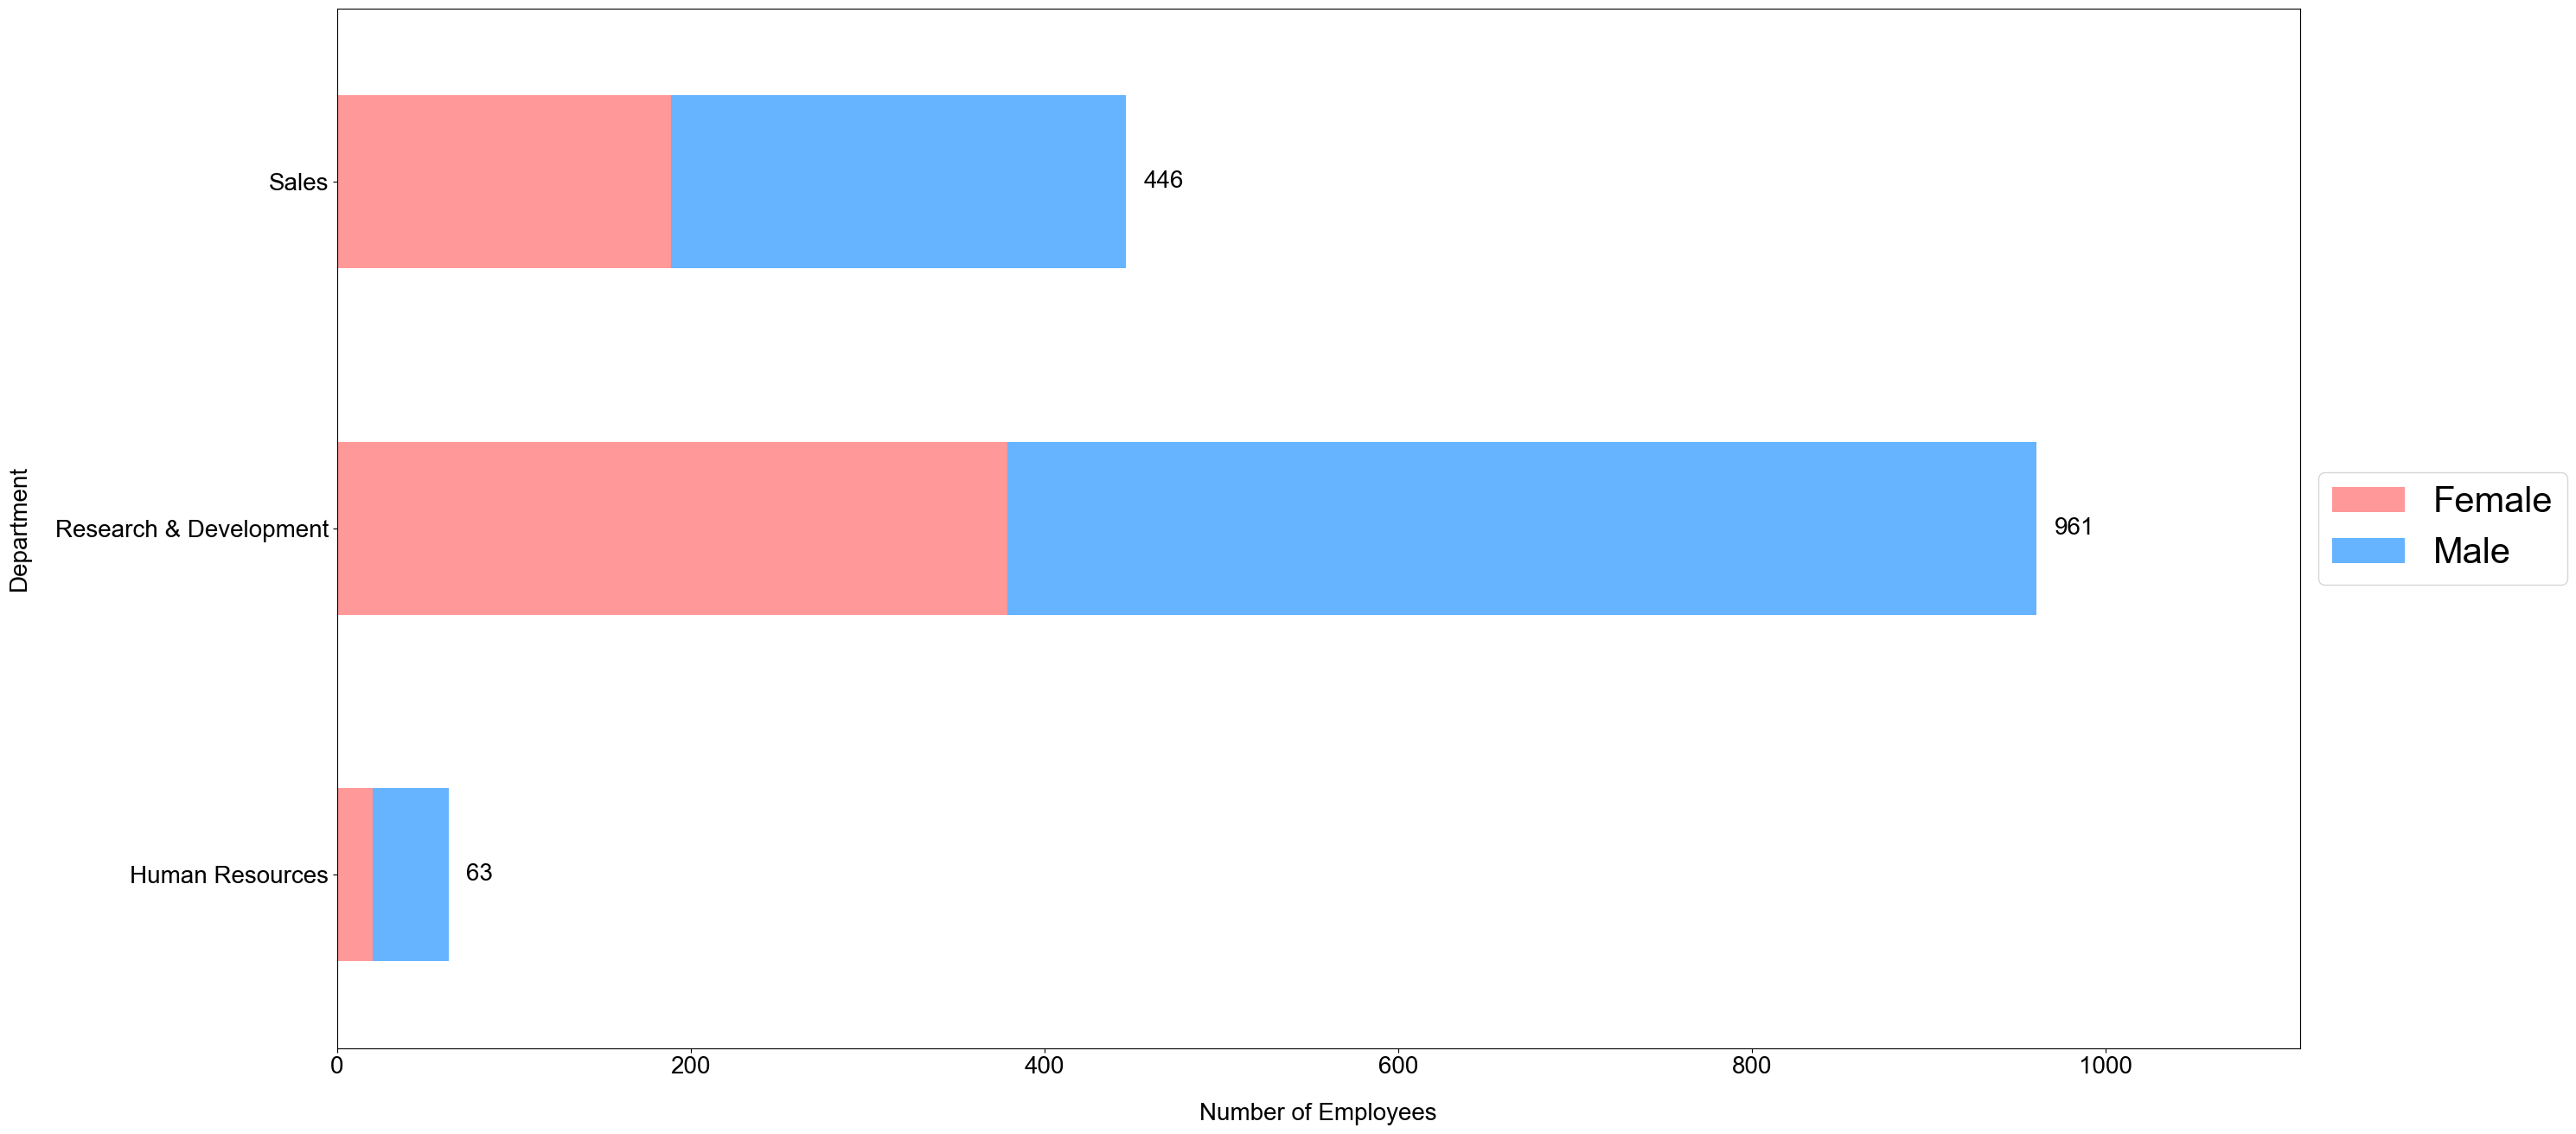

In [71]:
print(str(ibm_df['Department'].unique().tolist()) + "\n" + str(ibm_df['JobRole'].unique().tolist()))

primary_category = 'Department'
stacked_category = 'Gender'

data_to_plot = pd.crosstab(ibm_df[primary_category], ibm_df[stacked_category])

ax = data_to_plot.plot(kind='barh', 
                       stacked=True, 
                       figsize=(29.89, 13.21),
                       color=[COLOR_FEMALE, COLOR_MALE])

ax.set_title('')

ax.set_xlabel('Number of Employees', fontsize=DESCRIPTION_FONTSIZE, labelpad=20) 
ax.set_ylabel('Department', fontsize=DESCRIPTION_FONTSIZE, labelpad=20)

plt.xticks(fontsize=DESCRIPTION_FONTSIZE)
plt.yticks(rotation=0, fontsize=DESCRIPTION_FONTSIZE)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=DESCRIPTION_FONTSIZE+10)

totals = data_to_plot.sum(axis=1)
offset = ax.get_xlim()[1] * 0.01

for i, total in enumerate(totals):
    # The 'total + (total*0.01)' part adds a small gap after the bar.
    ax.text(total + offset, i, str(total),
            va='center', fontsize=DESCRIPTION_FONTSIZE)
    
ax.set_xlim(right=ax.get_xlim()[1] * 1.1)

plt.tight_layout()

plt.savefig('reports/department_stacked_barh.png', dpi=RESOLUTION)